In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("D:\Deep Learning\DailyDelhiClimate.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df= df[['date', 'meantemp']]
df 

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000
...,...,...
1571,2017-04-20,34.500000
1572,2017-04-21,34.250000
1573,2017-04-22,32.900000
1574,2017-04-23,32.875000


In [10]:
df['date'] = pd.to_datetime(df['date'])

df['day'] = np.arange(len(df))

df.head()

,date,meantemp,day
0,2013-01-01,10.000000,0
1,2013-01-02,7.400000,1
2,2013-01-03,7.166667,2
3,2013-01-04,8.666667,3
4,2013-01-05,6.000000,4


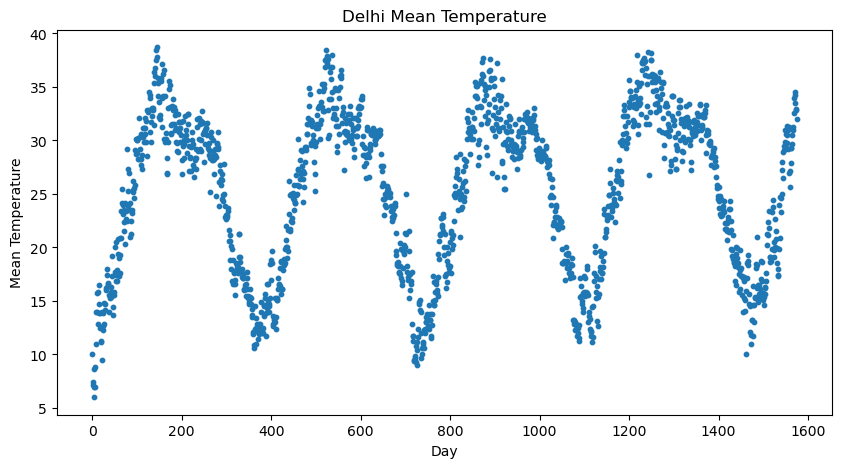

In [11]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df['day'],
    df['meantemp'],
    s=10
)

plt.xlabel("Day")
plt.ylabel("Mean Temperature")
plt.title("Delhi Mean Temperature")

plt.show()

In [12]:
X = df[['day']].values
y = df['meantemp'].values

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(1,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

In [18]:
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 237.7276 - mae: 11.7451 - val_loss: 69.6415 - val_mae: 6.4882
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 55.5816 - mae: 6.4937 - val_loss: 52.8584 - val_mae: 6.3030
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.7709 - mae: 6.3744 - val_loss: 52.8584 - val_mae: 6.3030
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.8271 - mae: 6.3969 - val_loss: 53.2713 - val_mae: 6.2716
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.8362 - mae: 6.3933 - val_loss: 52.9841 - val_mae: 6.2900
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.9389 - mae: 6.4144 - val_loss: 53.1293 - val_mae: 6.2794
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 53.9142 - mae: 6.3376 - val_loss: 52.8438 - val_mae: 6.3782
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 53.9968 - mae: 6.4137 - val_loss: 52.8008 - val_mae: 6.3134
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

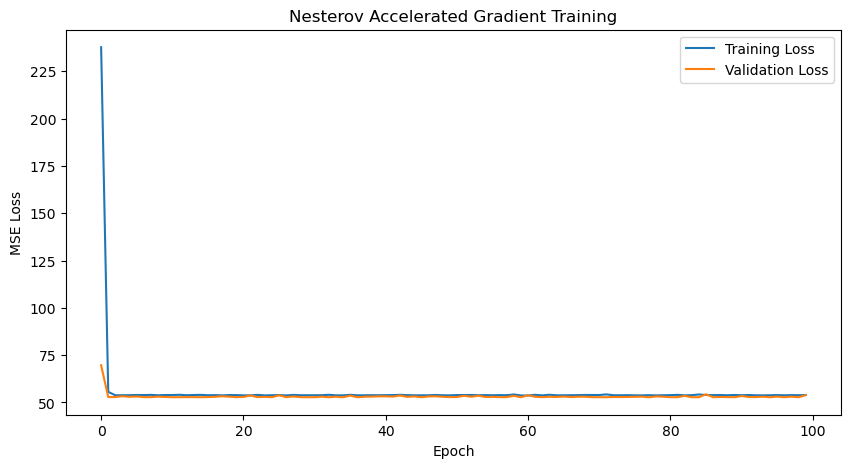

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Nesterov Accelerated Gradient Training")

plt.legend()
plt.show()

In [21]:
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 55.99310352490043
MAE: 6.490590435303456
R2 Score: -0.009271428465782883


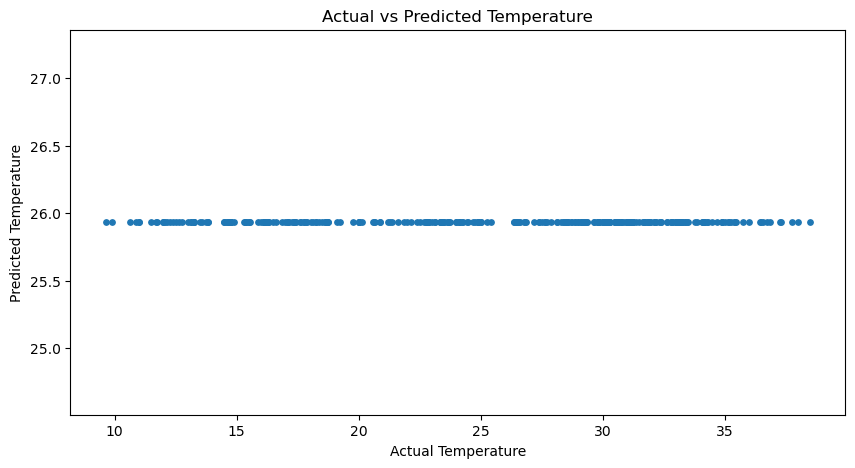

In [23]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred, s=15)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

plt.show()